In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# ============================================================
# Model registry: single source of truth for every forecast series.
# Add or remove a model HERE and it flows through all tables & plots below.
# ============================================================
# Each entry: label -> dict(pred, obs, color, marker, in_common)
#   pred/obs    : CSV basenames in ../../data
#   color/marker: styling for the trajectory & per-country plots
#   in_common   : whether the model joins the shared-grid intersection used by the
#                 headline RMSE tables. 
#
# The DL square series:
#   'DL square'  -- 5-seed ENSEMBLE (per-cell mean over seeds 0-4) of the tuned
#                   square_unlimited model, built by code/dl_training/
#                   train_dl_cohort_ensemble.py. Preferred over any single run: a
#                   single seed has large training variance (per-JOY RMSE ~2x
#                   swings, mean per-cell SD ~0.007) that inflated the JOY-1995
#                   spike in the old single run (spike ratio 1.65 -> 1.33 for the
#                   ensemble; ensemble is also better overall, 0.01199 vs 0.01247).
#                   Per-cell seed spread: dl_forecasts_square_ensemble_seedsd.csv.
#                   The old single-seed (SEED=42) run is kept commented below for
#                   before/after comparison.
# NOTE: each DL variant is scored against ITS OWN observed file. square (ACY) and
# parallelogram (ARDY) measure different quantities, so their observed rates differ
# -- never score one against the other's obs.
MODEL_REGISTRY = {
    'LeeCarter':        dict(pred='lee2_forecasts_cohort',                obs='lee2_obs_cohort',                       color='#d62728', marker='o', in_common=True),
    'DL square':        dict(pred='dl_forecasts_square_ensemble',         obs='dl_obs_cohort_square_ensemble',         color='#1f77b4', marker='s', in_common=True),
    #'DL square (1seed)':dict(pred='dl_forecasts_square_unlimited',        obs='dl_obs_cohort_square_unlimited',        color='#1f77b4', marker='s', in_common=True),
    #'DL parallelogram': dict(pred='dl_forecasts_parallelogram_unlimited', obs='dl_obs_cohort_parallelogram_unlimited', color='#17becf', marker='D', in_common=True),
    #'DL (prev)':        dict(pred='dl_forecasts_cohort_fewer_ages_refit', obs='dl_obs_cohort_fewer_ages_refit',        color='#7f7f7f', marker='v', in_common=True),
    'FreezeRates':      dict(pred='freeze_forecasts_cohort',              obs='freeze_obs_cohort',                     color='#2ca02c', marker='^', in_common=True),
    'Myrskyla2013':     dict(pred='myrskyla_forecasts_cohort',            obs='myrskyla_obs_cohort',                   color='#9467bd', marker='P', in_common=True),
    'deBeer':           dict(pred='debeer2_forecasts_cohort',             obs='debeer2_obs_cohort',                    color='#ff7f0e', marker='X', in_common=True),
    'Schmertmann2013':  dict(pred='schmertmann2013_forecasts_cohort',     obs='schmertmann2013_obs_cohort',            color='#8c564b', marker='*', in_common=True),
    #'Sevcikova2016':    dict(pred='sevcikova_forecasts_cohort',           obs='sevcikova_obs_cohort',                  color='#e377c2', marker='h', in_common=False),
}

DATA_DIR = '../../data'
key_cols = ['Country', 'Year', 'Age', 'JumpOffYear']

# label -> mutable dict with loaded frames + styling
M = {}
for label, meta in MODEL_REGISTRY.items():
    M[label] = {
        'pred':  pd.read_csv(f"{DATA_DIR}/{meta['pred']}.csv"),
        'obs':   pd.read_csv(f"{DATA_DIR}/{meta['obs']}.csv"),
        'color': meta['color'], 'marker': meta['marker'], 'in_common': meta['in_common'],
    }

# models that share the common forecast grid (everything except Schmertmann)
common_labels = [l for l, m in M.items() if m['in_common']]
print("Loaded models:  ", list(M))
print("Common grid:    ", common_labels)

Loaded models:   ['LeeCarter', 'DL square', 'FreezeRates', 'Myrskyla2013', 'deBeer', 'Schmertmann2013']
Common grid:     ['LeeCarter', 'DL square', 'FreezeRates', 'Myrskyla2013', 'deBeer', 'Schmertmann2013']


In [10]:
# Filter forecasts to only periods after the jump-off year (drop reproduced observed rates)
# Year is the birth cohort; the period of each observation is Year + Age.
for label, m in M.items():
    p = m['pred']
    m['pred'] = p[p['Year'] + p['Age'] > p['JumpOffYear']]

In [11]:
# Retain only rows shared across all common-grid models' forecasts (match on
# identifiers, not Rate). Schmertmann is excluded here (in_common=False) because it
# forecasts a restricted cohort set; see the diagnostic cell below.
common_keys = M[common_labels[0]]['pred'][key_cols].drop_duplicates()
for label in common_labels[1:]:
    common_keys = common_keys.merge(
        M[label]['pred'][key_cols].drop_duplicates(), on=key_cols, how='inner')

for label in common_labels:
    M[label]['pred'] = M[label]['pred'].merge(common_keys, on=key_cols, how='inner')

print(f"Common grid: {len(common_keys):,} cells across {len(common_labels)} models "
      f"({', '.join(common_labels)})")

Common grid: 63,075 cells across 6 models (LeeCarter, DL square, FreezeRates, Myrskyla2013, deBeer, Schmertmann2013)


In [12]:
# RMSE table: observed vs predicted rates for each forecast method.
# Every model is scored against its OWN observed frame (see registry note).
def rmse(pred_df, obs_df):
    merged = pred_df.merge(
        obs_df[key_cols + ['Rate']], on=key_cols, how='inner',
        suffixes=('_pred', '_obs')
    )
    err = np.sqrt(np.mean((merged['Rate_pred'] - merged['Rate_obs']) ** 2))
    return err, len(merged)

rmse_rows = []
for label, m in M.items():
    err, n = rmse(m['pred'], m['obs'])
    rmse_rows.append({'Method': label, 'RMSE': err, 'N': n})

rmse_table = pd.DataFrame(rmse_rows).sort_values('RMSE').reset_index(drop=True)
rmse_table

,Method,RMSE,N
0,DL square,0.011990,53112
1,Schmertmann2013,0.012558,53112
2,Myrskyla2013,0.012787,53112
3,deBeer,0.012913,53112
4,FreezeRates,0.013991,53112
5,LeeCarter,0.016584,53112


In [13]:
# RMSE by jump-off year for each common-grid method
def rmse_by_joy(pred_df, obs_df):
    merged = pred_df.merge(
        obs_df[key_cols + ['Rate']], on=key_cols, how='inner',
        suffixes=('_pred', '_obs')
    )
    return merged.groupby('JumpOffYear').apply(
        lambda d: np.sqrt(np.mean((d['Rate_pred'] - d['Rate_obs']) ** 2))
    )

rmse_joy_table = pd.concat(
    [rmse_by_joy(M[l]['pred'], M[l]['obs']).rename(l) for l in common_labels],
    axis=1,
)
rmse_joy_table

,LeeCarter,DL square,FreezeRates,Myrskyla2013,deBeer,Schmertmann2013
JumpOffYear,,,,,,
1985,0.016682,0.013608,0.013593,0.011501,0.011924,0.011119
1990,0.017303,0.011564,0.015428,0.014024,0.014873,0.013096
1995,0.018775,0.015376,0.016093,0.015268,0.015315,0.015295
2000,0.017964,0.011903,0.015303,0.012942,0.013740,0.012594
2005,0.012501,0.008770,0.011892,0.009740,0.010301,0.010853
2010,0.015241,0.009987,0.009742,0.011866,0.009288,0.010802


In [14]:
# ============================================================
# Completed cohort fertility (CCF): absolute percentage errors
# ============================================================
# Following Bohk-Ewald's stochastic-dominance procedure, the unit of comparison
# is the completed cohort fertility of a cohort, CCF = sum of ASFR over the
# reproductive ages (15-44, the span all forecasts share). For every completed
# cohort we take the absolute percentage error (APE) of the forecast CCF vs. the
# observed CCF, then compare the models' APE distributions with KS tests below.
#
# A cohort's forecast CCF combines its *known* history (observed rates for ages
# up to the jump-off year) with the model's forecast for the remaining ages, so
# only cohorts that were still incomplete at the jump-off year -- yet fully
# observed by the end of the data -- are genuine forecasts and are kept.
from scipy.stats import ks_2samp

AGES_LO, AGES_HI = 15, 44
N_AGES = AGES_HI - AGES_LO + 1          # 30 ages define a "completed" cohort
DOMINANCE_ALPHA = 0.05

# name -> (observed df, forecast df), built from the registry. Common-grid
# forecasts are already filtered to the shared post-jump-off cells (cells above).
models = {label: (m['obs'], m['pred']) for label, m in M.items()}


def ccf_ape(obs_df, pred_df):
    """APE (%) of completed cohort fertility, indexed by (Country, Year, JumpOffYear)."""
    obs = (obs_df[obs_df['Age'].between(AGES_LO, AGES_HI)]
           [['Country', 'Year', 'Age', 'Rate']]
           .drop_duplicates(['Country', 'Year', 'Age']))

    # true CCF: cohorts fully observed across all 30 ages (actually completed)
    n_obs_ages = obs.groupby(['Country', 'Year'])['Age'].transform('nunique')
    true_ccf = obs[n_obs_ages == N_AGES].groupby(['Country', 'Year'])['Rate'].sum()

    apes = {}
    for joy in sorted(pred_df['JumpOffYear'].unique()):
        obs_hist = obs[obs['Year'] + obs['Age'] <= joy]                      # known history
        fcast = pred_df[pred_df['JumpOffYear'] == joy][['Country', 'Year', 'Age', 'Rate']]
        traj = pd.concat([obs_hist, fcast])                                  # reconstructed trajectory
        n_traj_ages = traj.groupby(['Country', 'Year'])['Age'].transform('nunique')
        fcast_ccf = traj[n_traj_ages == N_AGES].groupby(['Country', 'Year'])['Rate'].sum()

        for (country, byear) in fcast_ccf.index.intersection(true_ccf.index):
            if joy - byear < N_AGES + AGES_LO - 1:   # cohort not yet complete at jump-off
                obs_v, fc_v = true_ccf[(country, byear)], fcast_ccf[(country, byear)]
                apes[(country, byear, joy)] = abs(fc_v - obs_v) / obs_v * 100
    return pd.Series(apes, name='APE')


ape_by_model = {name: ccf_ape(o, p) for name, (o, p) in models.items()}

# Equalize the testing dataset: keep only cohorts evaluated by *every* model, so
# all pairwise KS tests compare distributions over the identical set of cohorts.
common_cohorts = None
for s in ape_by_model.values():
    common_cohorts = s.index if common_cohorts is None else common_cohorts.intersection(s.index)
ape_by_model = {name: s.loc[common_cohorts] for name, s in ape_by_model.items()}

ape_summary = pd.DataFrame({
    'N':          {n: len(s)      for n, s in ape_by_model.items()},
    'median_APE': {n: s.median()  for n, s in ape_by_model.items()},
    'mean_APE':   {n: s.mean()    for n, s in ape_by_model.items()},
}).sort_values('median_APE')
ape_summary

,N,median_APE,mean_APE
Myrskyla2013,2930,0.711642,3.267985
deBeer,2930,0.796691,3.266207
DL square,2930,0.936348,3.499094
Schmertmann2013,2930,0.975574,2.964461
LeeCarter,2930,1.215429,4.360414
FreezeRates,2930,1.530554,3.648789


In [22]:
# ============================================================
# CCF-APE percentile thresholds per method
# ============================================================
# For each method, the CCF-APE value below which 50 / 80 / 90 / 95% of the
# completed-cohort forecasts fall -- i.e. percentiles of the same APE
# distributions summarized above (`ape_by_model`, over the common cohort set).
# APE is already in percent, so the thresholds are read as "X% of cohorts have
# APE <= this many %". Sorted by the median (P50); lower = tighter errors.
PCTS = [50, 80, 90, 95]
ape_thresholds = pd.DataFrame(
    {f'P{p}': {name: np.percentile(s.values, p) for name, s in ape_by_model.items()}
     for p in PCTS}
).sort_values('P50')
print('CCF-APE thresholds (%): X% of cohorts have APE at or below the value')
ape_thresholds.round(3)

CCF-APE thresholds (%): X% of cohorts have APE at or below the value


,P50,P80,P90,P95
Myrskyla2013,0.712,5.275,10.689,16.031
deBeer,0.797,5.898,10.037,13.984
DL square,0.936,6.193,10.626,15.318
Schmertmann2013,0.976,4.680,8.317,12.268
LeeCarter,1.215,7.526,13.718,18.563
FreezeRates,1.531,7.116,10.437,13.003


In [15]:
# ============================================================
# Two-sided KS: are the CCF-APE distributions equal across models?
# ============================================================
# H0: the two models' APE CDFs are identical. A small p-value means the models'
# completed-cohort-fertility error distributions differ significantly.
names = list(ape_by_model)
ks2_stat = pd.DataFrame(index=names, columns=names, dtype=float)
ks2_pval = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        res = ks_2samp(ape_by_model[a].values, ape_by_model[b].values)
        ks2_stat.loc[a, b] = res.statistic
        ks2_pval.loc[a, b] = res.pvalue

print('Two-sided KS statistic  (max gap between APE CDFs):')
display(ks2_stat.round(3))
print('\nTwo-sided KS p-value  (H0: equal APE distributions):')
display(ks2_pval.round(4))


Two-sided KS statistic  (max gap between APE CDFs):


,LeeCarter,DL square,FreezeRates,Myrskyla2013,deBeer,Schmertmann2013
LeeCarter,0.000,0.082,0.061,0.085,0.064,0.090
DL square,0.082,0.000,0.080,0.111,0.102,0.088
FreezeRates,0.061,0.080,0.000,0.124,0.094,0.102
Myrskyla2013,0.085,0.111,0.124,0.000,0.036,0.066
deBeer,0.064,0.102,0.094,0.036,0.000,0.049
Schmertmann2013,0.090,0.088,0.102,0.066,0.049,0.000



Two-sided KS p-value  (H0: equal APE distributions):


,LeeCarter,DL square,FreezeRates,Myrskyla2013,deBeer,Schmertmann2013
LeeCarter,1.0,0.0,0.0,0.0000,0.0000,0.0000
DL square,0.0,1.0,0.0,0.0000,0.0000,0.0000
FreezeRates,0.0,0.0,1.0,0.0000,0.0000,0.0000
Myrskyla2013,0.0,0.0,0.0,1.0000,0.0464,0.0000
deBeer,0.0,0.0,0.0,0.0464,1.0000,0.0019
Schmertmann2013,0.0,0.0,0.0,0.0000,0.0019,1.0000


In [16]:
# ============================================================
# One-sided KS: stochastic dominance  KS(A, B)
# ============================================================
# KS(A, B) tests whether A's APE CDF is strictly greater (lies to the LEFT) of
# B's -- i.e. A's completed-cohort-fertility errors are systematically smaller,
# so A stochastically dominates (forecasts better than) B.
#   scipy alternative='greater' -> H1: CDF_A > CDF_B  (statistic = sup(F_A - F_B))
# A small p-value in cell (row=A, col=B) => A dominates B.
ksd_stat = pd.DataFrame(index=names, columns=names, dtype=float)
ksd_pval = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        if a == b:
            ksd_stat.loc[a, b], ksd_pval.loc[a, b] = 0.0, 1.0
            continue
        res = ks_2samp(ape_by_model[a].values, ape_by_model[b].values,
                       alternative='greater')
        ksd_stat.loc[a, b] = res.statistic
        ksd_pval.loc[a, b] = res.pvalue

# For each model: which rivals it significantly dominates / is dominated by
dominates = ksd_pval < DOMINANCE_ALPHA          # (row dominates column)
dominance_scoreboard = pd.DataFrame({
    'dominates_n':    dominates.sum(axis=1),
    'dominated_by_n': dominates.sum(axis=0),
}).sort_values(['dominates_n', 'dominated_by_n'], ascending=[False, True])

print('One-sided KS(A,B) statistic  sup(F_A - F_B):')
display(ksd_stat.round(3))
print(f'\nStochastic dominance at alpha={DOMINANCE_ALPHA}  (True: row dominates column):')
display(dominates)
print('\nScoreboard: how many of the other models each model beats')
dominance_scoreboard


One-sided KS(A,B) statistic  sup(F_A - F_B):


,LeeCarter,DL square,FreezeRates,Myrskyla2013,deBeer,Schmertmann2013
LeeCarter,0.000,0.082,0.045,0.003,0.004,0.014
DL square,0.044,0.000,0.080,0.007,0.001,0.024
FreezeRates,0.061,0.068,0.000,0.032,0.016,0.012
Myrskyla2013,0.085,0.111,0.124,0.000,0.036,0.066
deBeer,0.064,0.102,0.094,0.017,0.000,0.049
Schmertmann2013,0.090,0.088,0.102,0.036,0.044,0.000



Stochastic dominance at alpha=0.05  (True: row dominates column):


,LeeCarter,DL square,FreezeRates,Myrskyla2013,deBeer,Schmertmann2013
LeeCarter,False,True,True,False,False,False
DL square,True,False,True,False,False,False
FreezeRates,True,True,False,False,False,False
Myrskyla2013,True,True,True,False,True,True
deBeer,True,True,True,False,False,True
Schmertmann2013,True,True,True,True,True,False



Scoreboard: how many of the other models each model beats


,dominates_n,dominated_by_n
Myrskyla2013,5,1
Schmertmann2013,5,2
deBeer,4,2
LeeCarter,2,5
DL square,2,5
FreezeRates,2,5


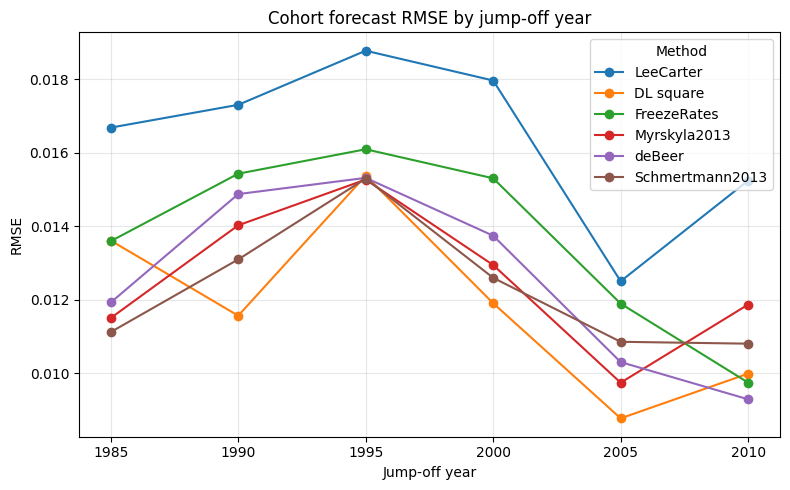

In [17]:
# Plot RMSE by jump-off year for each method
fig, ax = plt.subplots(figsize=(8, 5))
for method in rmse_joy_table.columns:
    ax.plot(rmse_joy_table.index, rmse_joy_table[method], marker='o', label=method)

ax.set_xlabel('Jump-off year')
ax.set_ylabel('RMSE')
ax.set_title('Cohort forecast RMSE by jump-off year')
ax.legend(title='Method')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

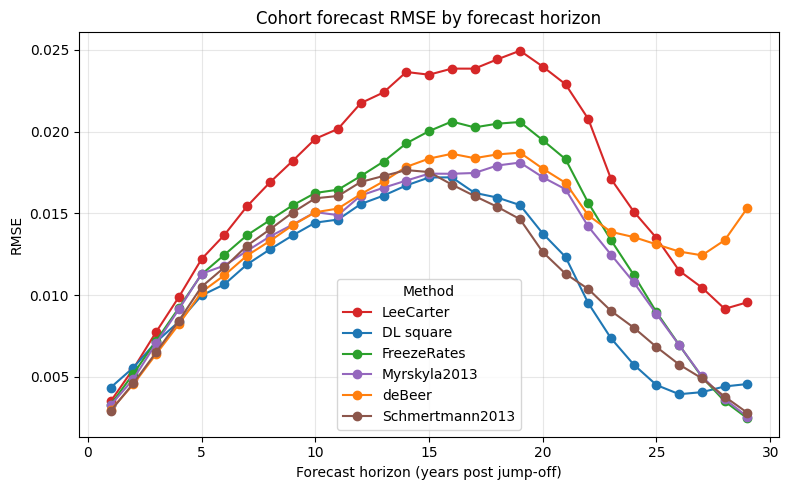

In [18]:
# RMSE by forecast horizon (years post jump-off) for each common-grid method.
# Horizon = period (Year + Age) - JumpOffYear
def rmse_by_horizon(pred_df, obs_df):
    merged = pred_df.merge(
        obs_df[key_cols + ['Rate']], on=key_cols, how='inner',
        suffixes=('_pred', '_obs')
    )
    merged['Horizon'] = merged['Year'] + merged['Age'] - merged['JumpOffYear']
    return merged.groupby('Horizon').apply(
        lambda d: np.sqrt(np.mean((d['Rate_pred'] - d['Rate_obs']) ** 2))
    )

rmse_horizon_table = pd.concat(
    [rmse_by_horizon(M[l]['pred'], M[l]['obs']).rename(l) for l in common_labels],
    axis=1,
)

fig, ax = plt.subplots(figsize=(8, 5))
for label in rmse_horizon_table.columns:
    ax.plot(rmse_horizon_table.index, rmse_horizon_table[label], marker='o',
            color=M[label]['color'], label=label)

ax.set_xlabel('Forecast horizon (years post jump-off)')
ax.set_ylabel('RMSE')
ax.set_title('Cohort forecast RMSE by forecast horizon')
ax.legend(title='Method')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

{0: np.str_('AUT'), 1: np.str_('BEL'), 2: np.str_('BGR'), 3: np.str_('BLR'), 4: np.str_('CAN'), 5: np.str_('CHE'), 6: np.str_('CHL'), 7: np.str_('CZE'), 8: np.str_('DEUTE'), 9: np.str_('DEUTNP'), 10: np.str_('DEUTW'), 11: np.str_('DNK'), 12: np.str_('ESP'), 13: np.str_('EST'), 14: np.str_('FIN'), 15: np.str_('FRATNP'), 16: np.str_('GBR_NIR'), 17: np.str_('GBR_NP'), 18: np.str_('GBR_SCO'), 19: np.str_('GBRTENW'), 20: np.str_('HRV'), 21: np.str_('HUN'), 22: np.str_('IRL'), 23: np.str_('ISL'), 24: np.str_('ITA'), 25: np.str_('JPN'), 26: np.str_('KOR'), 27: np.str_('LTU'), 28: np.str_('NLD'), 29: np.str_('NOR'), 30: np.str_('POL'), 31: np.str_('PRT'), 32: np.str_('RUS'), 33: np.str_('SVK'), 34: np.str_('SVN'), 35: np.str_('SWE'), 36: np.str_('TWN'), 37: np.str_('UKR'), 38: np.str_('USA')}


KeyError: 'DL parallelogram'

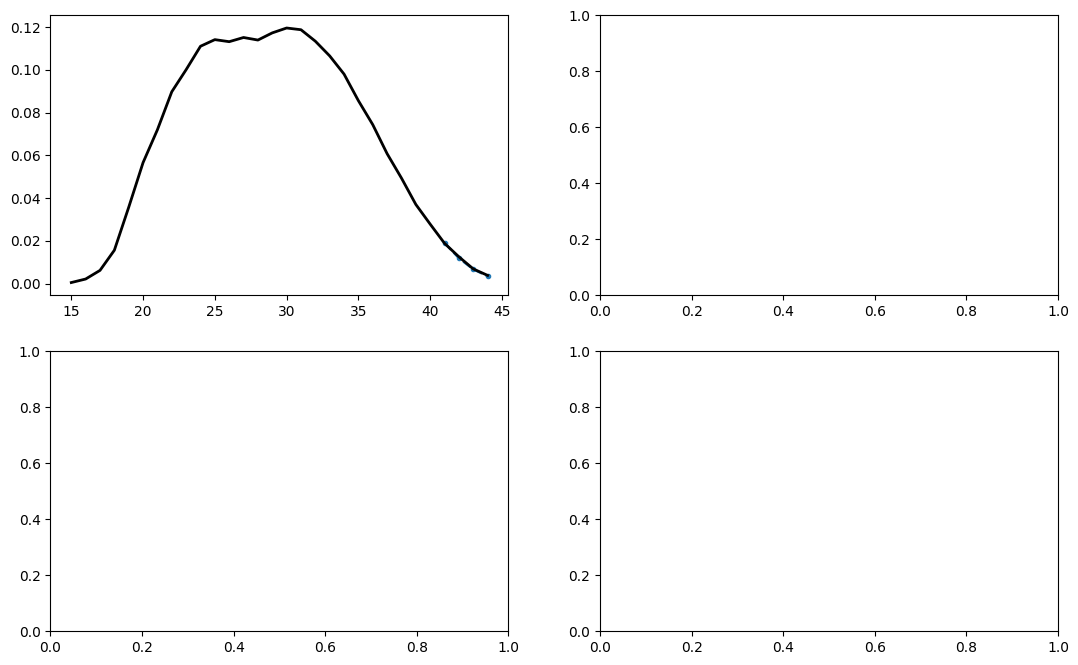

In [20]:
# ============================================================
# Observed vs. forecast cohort fertility trajectories
# ============================================================

# country index -> country code (for nicer titles)
_geos = np.load('../../data/geos_key.npy', allow_pickle=True)
GEO_NAMES = {int(idx): code for code, idx in _geos}
print(GEO_NAMES)

# Each method: label -> (observed_df, predicted_df, color), built from the registry.
METHODS = {label: (m['obs'], m['pred'], m['color']) for label, m in M.items()}
# NOTE: the black "observed" line uses methods[0]'s obs frame. Keep a DL series
# first so it stays the ACY-observed reference (parallelogram obs is ARDY).


def plot_cohort_forecasts(country, jump_off_year, birth_years,
                          methods=('DL square',)):
    """Trace observed vs. forecast ASFR over age for a selection of cohorts.

    One subplot per cohort (identified by birth `Year`). Observed rates are
    drawn as a solid black line across all ages; each method's forecast is a
    dashed colored line for the post-jump-off ages. A dotted vertical line
    marks the jump-off year, which for a cohort born in `by` sits at
    age = jump_off_year - by.
    """
    n = len(birth_years)
    ncols = min(2, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4 * nrows),
                             squeeze=False)
    axes = axes.ravel()

    for ax, by in zip(axes, birth_years):
        split_age = jump_off_year - by  # age at which the jump-off year falls

        # --- observed truth (from methods[0]'s obs frame) ---
        obs_df = METHODS[methods[0]][0]
        obs = obs_df[(obs_df['Country'] == country) &
                     (obs_df['JumpOffYear'] == jump_off_year) &
                     (obs_df['Year'] == by)].sort_values('Age')
        if not obs.empty:
            ax.plot(obs['Age'], obs['Rate'], '-', color='black', lw=2,
                    label='Observed (actual)', zorder=5)

        # --- each method's forecast, restricted to post-jump-off ages ---
        for label in methods:
            _, pred_df, color = METHODS[label]
            pred = pred_df[(pred_df['Country'] == country) &
                           (pred_df['JumpOffYear'] == jump_off_year) &
                           (pred_df['Year'] == by)].sort_values('Age')
            fc = pred[(pred['Year'] + pred['Age']) > jump_off_year]
            if not fc.empty:
                ax.plot(fc['Age'], fc['Rate'], '--', color=color, lw=1.8,
                        marker='o', markersize=3, label=f'{label} forecast')

        # --- jump-off marker ---
        if obs['Age'].min() <= split_age <= obs['Age'].max() if not obs.empty else True:
            ax.axvline(split_age, color='gray', ls=':', lw=1.5)
            ax.text(split_age, ax.get_ylim()[1] * 0.98,
                    f' jump-off {jump_off_year}', rotation=90,
                    va='top', ha='left', fontsize=8, color='gray')

        ax.set_title(f'{GEO_NAMES.get(country, country)} — cohort born {by}')
        ax.set_xlabel('Age')
        ax.set_ylabel('ASFR')
        ax.legend(fontsize=8)

    # hide any unused axes
    for ax in axes[len(birth_years):]:
        ax.set_visible(False)

    fig.suptitle(f'Cohort fertility: observed vs. forecast '
                 f'(jump-off {jump_off_year})', fontsize=13)
    plt.tight_layout()
    return fig


fig = plot_cohort_forecasts(
    country=35,
    jump_off_year=2010,
    birth_years=[1970, 1975, 1980, 1990],
    methods=('DL square', 'DL parallelogram', 'LeeCarter', 'FreezeRates', 'Myrskyla2013'),
)
#fig.savefig('../../figures/cohort_forecast_trajectories_irl_1990.png', dpi=300,
       #     bbox_inches='tight')
plt.show()

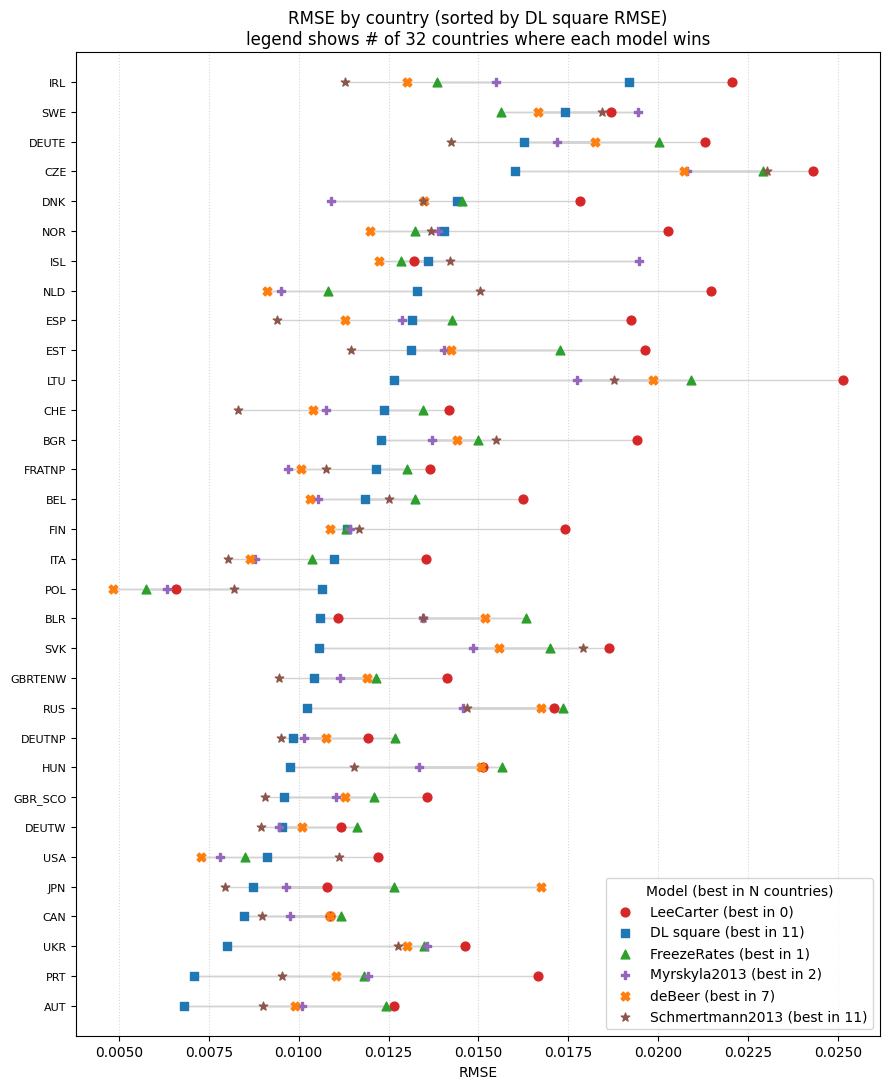

In [21]:
# ============================================================
# RMSE by country, common-grid methods (dot plot, sorted by DL square RMSE)
# ============================================================
def _rmse(d):
    return np.sqrt(np.mean((d['Rate_pred'] - d['Rate_obs']) ** 2))

SORT_BY = 'DL square'
plot_labels = common_labels   # models on the shared grid (excludes Schmertmann)

# Merge each method's forecasts with its observed rates on the shared keys
merged_by_model = {
    l: M[l]['pred'].merge(
        M[l]['obs'][key_cols + ['Rate']], on=key_cols, how='inner',
        suffixes=('_pred', '_obs')
    )
    for l in plot_labels
}

rmse_country = pd.DataFrame({
    l: dfm.groupby('Country').apply(_rmse)
    for l, dfm in merged_by_model.items()
})

# for each country, which model has the lowest RMSE -> count wins per model
best_counts = rmse_country.idxmin(axis=1).value_counts()

# sort countries by the reference DL series for readability
rmse_country = rmse_country.sort_values(SORT_BY)
labels = [GEO_NAMES.get(int(c), str(c)) for c in rmse_country.index]
y = np.arange(len(rmse_country))

fig, ax = plt.subplots(figsize=(9, 11))
for l in plot_labels:
    legend_label = f'{l} (best in {best_counts.get(l, 0)})'
    ax.scatter(rmse_country[l], y, color=M[l]['color'], label=legend_label,
               marker=M[l]['marker'], s=40, zorder=3)

# faint connector so each country's spread is easy to read
for yi in y:
    ax.plot(rmse_country.iloc[yi].values, [yi] * rmse_country.shape[1],
            color='lightgray', lw=1, zorder=1)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_ylim(-1, len(y))
ax.set_xlabel('RMSE')
ax.set_title(f'RMSE by country (sorted by {SORT_BY} RMSE)\n'
             f'legend shows # of {len(rmse_country)} countries where each model wins')
ax.legend(title='Model (best in N countries)')
ax.grid(axis='x', ls=':', alpha=0.5)
plt.tight_layout()
plt.savefig('../../figures/rmse_by_country.png', dpi=300, bbox_inches='tight')
plt.show()